In [ ]:
pip install Cython

In [ ]:
pip install pyEDFlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 23.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

In [ ]:
pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9656 sha256=9169ab14bfef0ff06189f8584e895ba6dcc127d650420d89cb9b7cc84b9e0516
  Stored in directory: /root/.cache/pip/wheels/8b/f1/7f/5c94f0a7a505ca1c81cd1d9208ae2064675d97582078e6c769
Successfully built wget


In [ ]:
import pyedflib
import subprocess

# Скачать набор данных
url = 'https://physionet.org/static/published-projects/eegmat/eeg-during-mental-arithmetic-tasks-1.0.0.zip'
filename = 'eegmat-1.0.0.zip'

subprocess.run(['wget', url, '-O', filename])

# Распаковать набор данных
subprocess.run(['unzip', filename])

# Ваш вариант
variant = 3

# Пути к файлам
path1 = f'/content/eeg-during-mental-arithmetic-tasks-1.0.0/Subject0{variant}_1.edf'
path2 = f'/content/eeg-during-mental-arithmetic-tasks-1.0.0/Subject0{variant}_2.edf'

In [ ]:
# Чтение файлов и получение количества каналов
reader1 = pyedflib.EdfReader(path1)
s_1 = reader1.signals_in_file
reader1.close()
reader2 = pyedflib.EdfReader(path2)
s_2 = reader2.signals_in_file
reader2.close()
print(s_1, s_2)

21 21


In [ ]:
# Получить метки датчиков
signal_labels_1 = reader1.getSignalLabels()
signal_labels_2 = reader2.getSignalLabels()

In [ ]:
# Чтение данных из первого файла
# Прочитать данные ЭЭГ с помощью метода read_edf()
signals_1, signal_headers_1, header_1 = pyedflib.highlevel.read_edf(path1)

# Получить информацию из заголовка
patient_info_1 = header_1['patientname']
patient_gender_1 = header_1['sex']
min_values_1 = [signal_header['physical_min'] for signal_header in signal_headers_1]
max_values_1 = [signal_header['physical_max'] for signal_header in signal_headers_1]
sample_frequency_1 = signal_headers_1[0]['sample_frequency']

print(f"Файл: {path1}")
print(f"Имя пациента: {patient_info_1}")
print(f"Пол пациента: {patient_gender_1}")
print(f"Метки датчиков: {signal_labels_1}")
print(f"Минимальные значения: {min_values_1}")
print(f"Максимальные значения: {max_values_1}")
print(f"Частота дискретизации: {sample_frequency_1}\n")

Файл: /content/eeg-during-mental-arithmetic-tasks-1.0.0/Subject03_1.edf
Имя пациента: Subject3
Пол пациента: Male
Метки датчиков: ['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1', 'ECG ECG']
Минимальные значения: [-58.5251, -46.5602, -48.387, -69.7321, -70.376, -158.048, -48.3031, -48.4609, -54.893, -48.856700000000004, -33.4909, -44.9983, -87.248, -63.2674, -60.7971, -70.8478, -47.7207, -64.6581, -76.1209, -28.7347, -0.13103]
Максимальные значения: [77.06744, 51.02391, 47.03392, 62.058840000000004, 59.92522, 156.3727, 47.98456, 52.26339, 56.59763, 48.2877, 46.96947, 46.81447, 92.88411, 53.54838, 67.96407, 56.4515, 50.80798, 69.08759, 74.10566, 28.42753, 0.423343]
Частота дискретизации: 500.0



In [ ]:
# Чтение данных из второго файла
# Прочитать данные ЭЭГ с помощью метода read_edf()
signals_2, signal_headers_2, header_2 = pyedflib.highlevel.read_edf(path2)

# Получить информацию из заголовка
patient_info_2 = header_2['patientname']
patient_gender_2 = header_2['sex']
min_values_2 = [signal_header['physical_min'] for signal_header in signal_headers_2]
max_values_2 = [signal_header['physical_max'] for signal_header in signal_headers_2]
sample_frequency_2 = signal_headers_2[0]['sample_frequency']

print(f"Файл: {path2}")
print(f"Имя пациента: {patient_info_2}")
print(f"Пол пациента: {patient_gender_2}")
print(f"Метки датчиков: {signal_labels_2}")
print(f"Минимальные значения: {min_values_2}")
print(f"Максимальные значения: {max_values_2}")
print(f"Частота дискретизации: {sample_frequency_2}\n")

Файл: /content/eeg-during-mental-arithmetic-tasks-1.0.0/Subject03_2.edf
Имя пациента: Subject3
Пол пациента: Male
Метки датчиков: ['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1', 'ECG ECG']
Минимальные значения: [-44.063, -81.3418, -28.7103, -40.2498, -33.9568, -22.7346, -30.0568, -28.6771, -33.9502, -35.7306, -26.4053, -51.3444, -38.2218, -37.2588, -42.0953, -44.4495, -31.3606, -34.1349, -37.1473, -51.5283, -0.12348]
Максимальные значения: [38.38036, 76.31117, 31.69247, 34.49428, 27.20691, 23.57263, 35.88792, 27.41395, 35.52765, 37.4495, 24.37612, 42.93614, 50.12154, 34.87662, 44.65926, 44.19214, 31.99408, 32.50068, 32.84244, 47.83299, 0.435738]
Частота дискретизации: 500.0



In [ ]:
# Получить сигналы ЭЭГ
eeg_signals1 = [signals_1[i] for i in range(20)]  # Все сигналы ЭЭГ
eeg_signals2 = [signals_2[i] for i in range(20)]  # Все сигналы ЭЭГ

# Преобразовать сигналы в DataFrame pandas
df1 = pd.DataFrame(np.array(eeg_signals1).T, columns=['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1'])
df2 = pd.DataFrame(np.array(eeg_signals2).T, columns=['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1'])

# Подготовка массивов данных для частотного анализа на основе Фурье преобразования
n1 = 20
n2 = 20
signal1 = np.zeros((n1, reader1.getNSamples()[0]))
signal2 = np.zeros((n2, reader2.getNSamples()[0]))

for i in range(n1):
    signal1[i, :] = df1.iloc[:, i].values

for i in range(n2):
    signal2[i, :] = df2.iloc[:, i].values

print(signal1.shape, signal2.shape)
print(signal1)

(20, 91000) (20, 31000)
[[ 5.88730490e+00  4.21140718e+00  2.13205259e+00 ...  9.72769970e-04
   9.72769970e-04  9.72769970e-04]
 [ 4.62250562e+00  3.45063266e+00  1.88863172e+00 ...  5.31450217e-04
   5.31450217e-04  5.31450217e-04]
 [ 3.46950516e+00  1.68732456e+00 -5.75345921e-01 ... -2.14107881e-04
  -2.14107881e-04 -2.14107881e-04]
 ...
 [ 4.95863880e+00  2.04433583e+00 -1.29854111e+00 ...  1.46658686e-03
   1.46658686e-03  1.46658686e-03]
 [ 3.88531648e+00  3.20679261e+00  2.92713075e+00 ... -1.49593042e-04
  -1.49593042e-04 -1.49593042e-04]
 [ 2.92565616e-01 -4.50582624e-01 -1.15796904e+00 ... -5.06929274e-04
  -5.06929274e-04 -5.06929274e-04]]


/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:3387: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval
/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


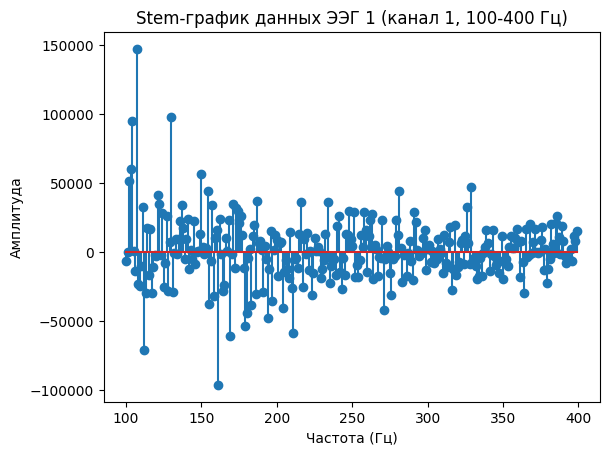

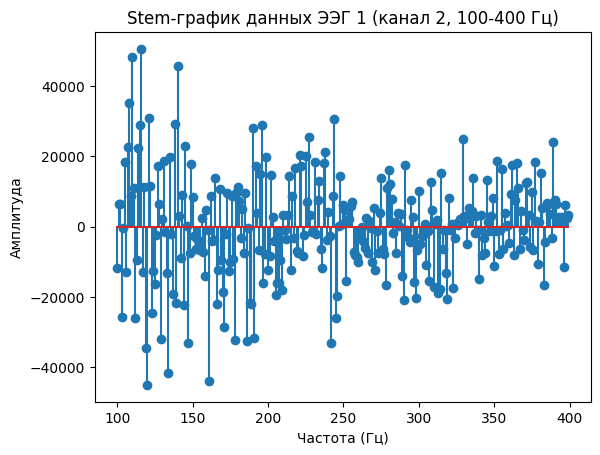

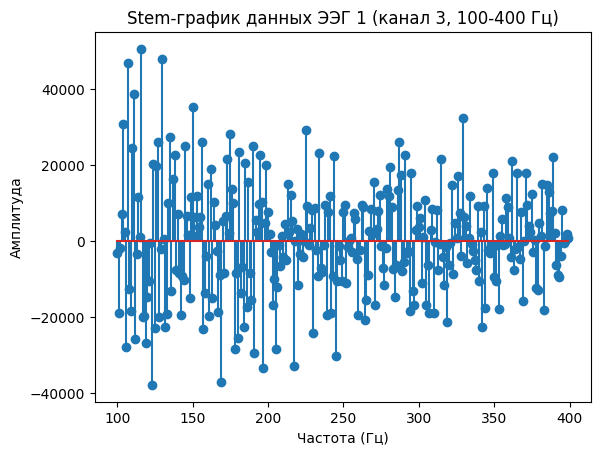

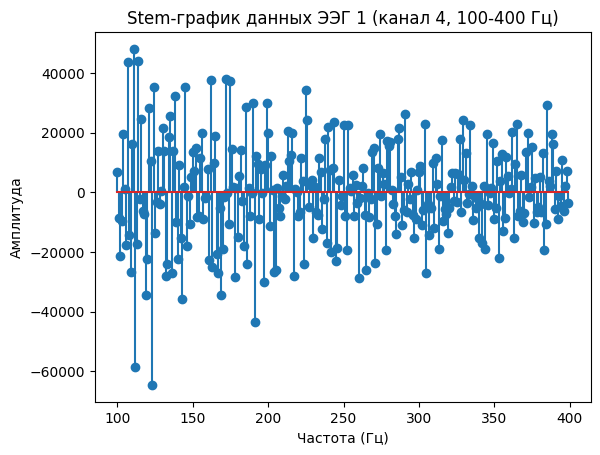

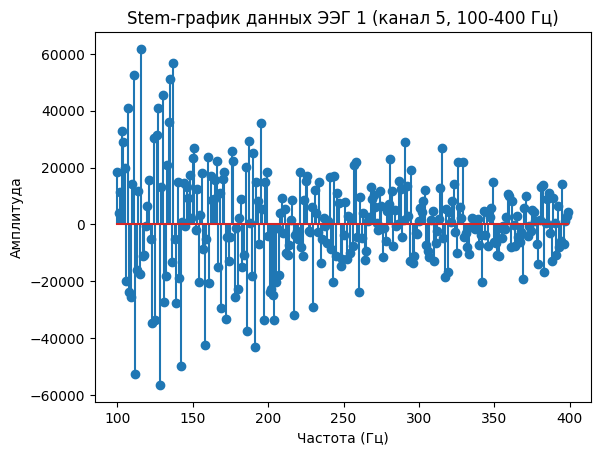

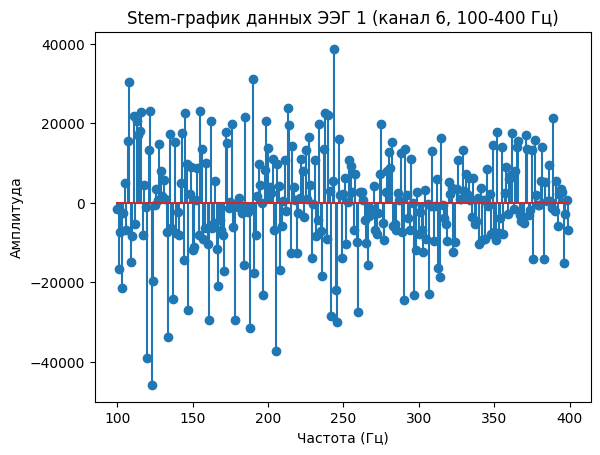

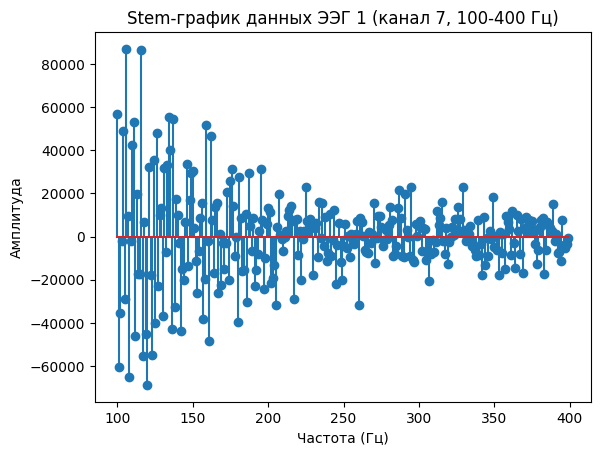

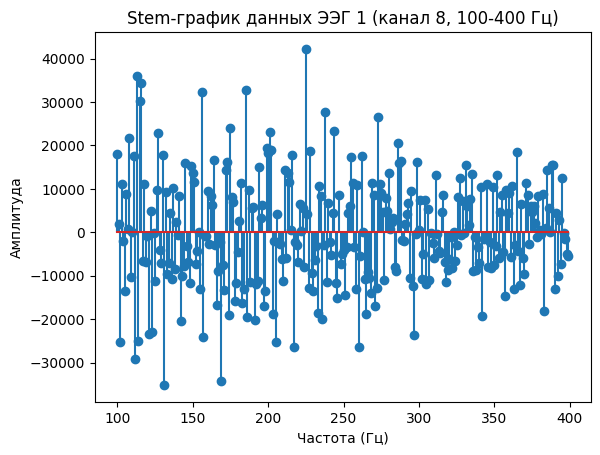

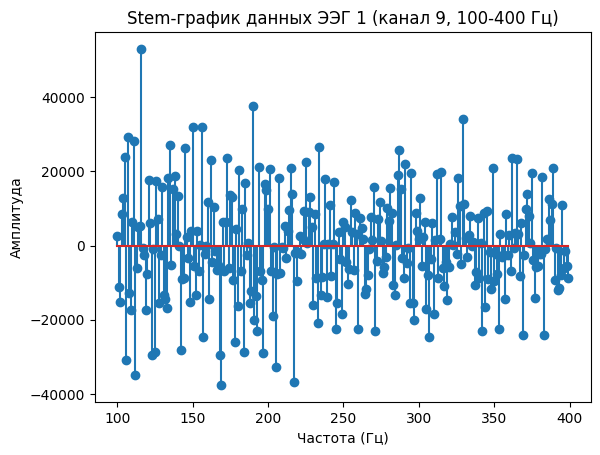

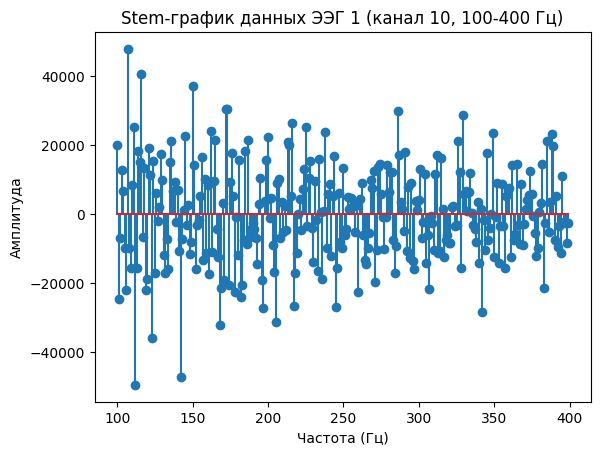

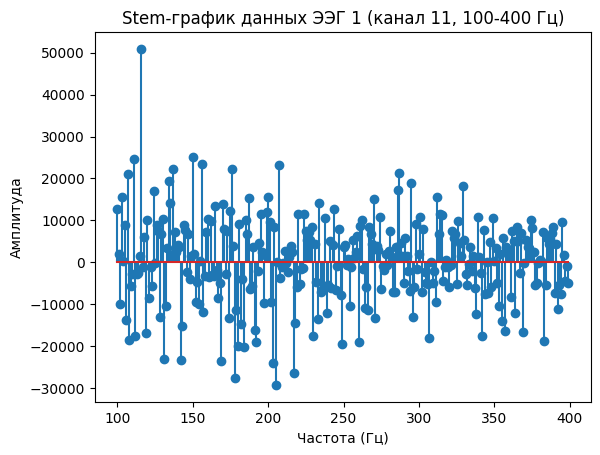

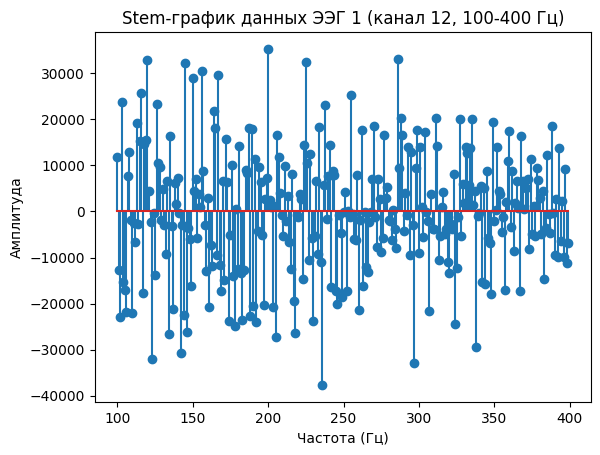

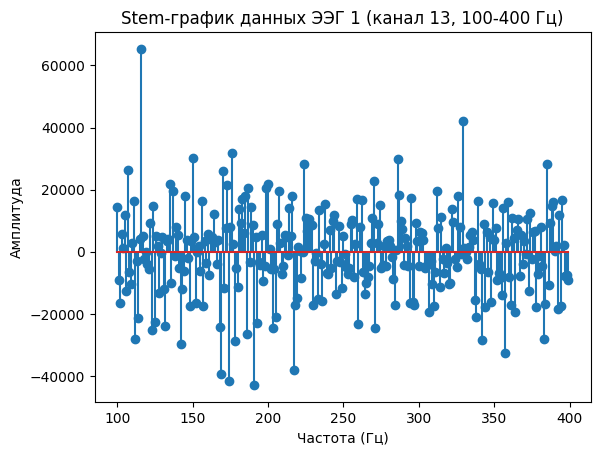

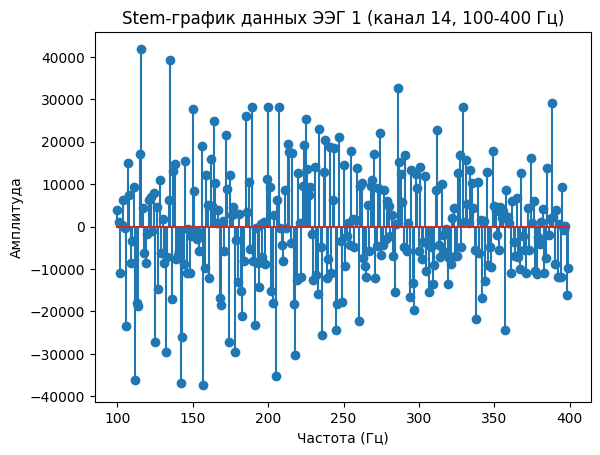

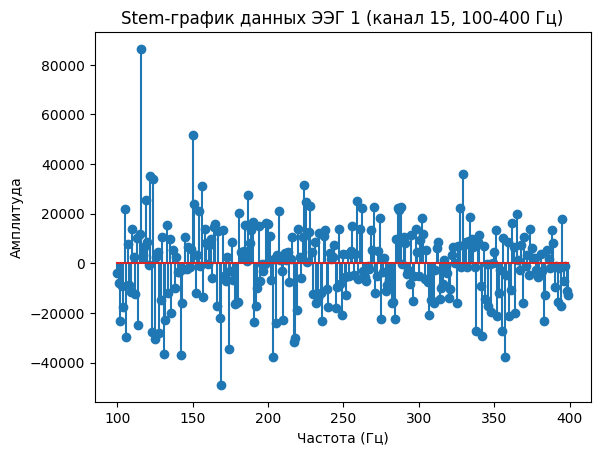

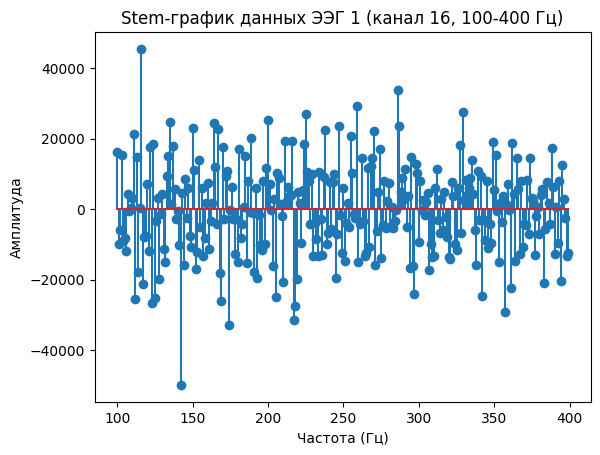

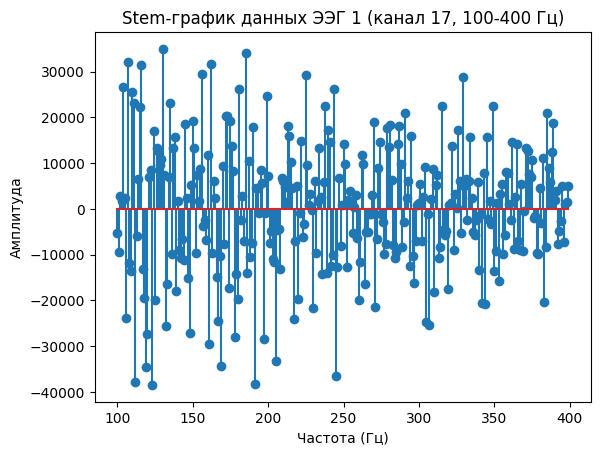

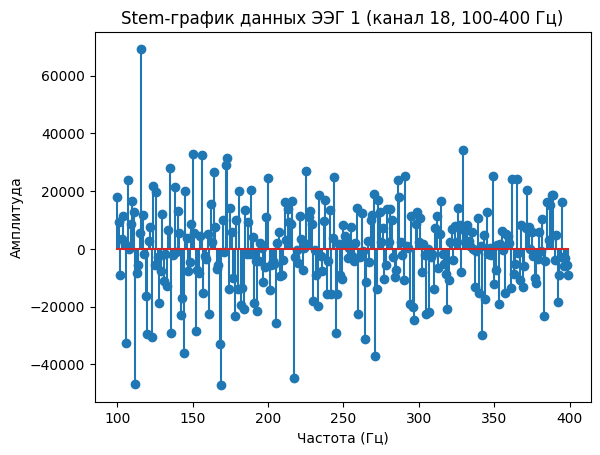

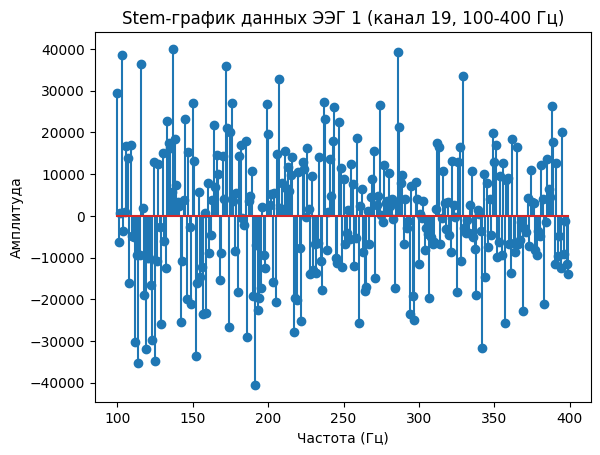

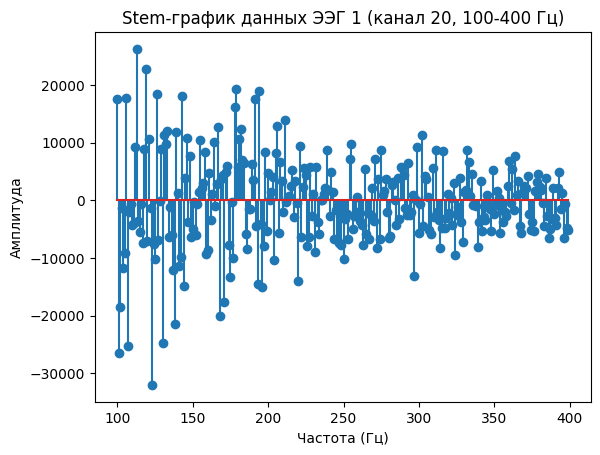

In [ ]:
# Графики ЭЭГ для первого файла

# Задать диапазон частот (100-400 Гц)
freq_range = np.arange(100, 400, 1)

fft_eeg_1 = np.fft.fft(eeg_signals1)
fft_eeg_100_400_1 = fft_eeg_1[:, 100:400]

for i in range(20):
    plt.stem(freq_range, fft_eeg_100_400_1[i, :])
    plt.xlabel("Частота (Гц)")
    plt.ylabel("Амплитуда")
    plt.title(f"Stem-график данных ЭЭГ 1 (канал {i+1}, 100-400 Гц)")
    plt.show()

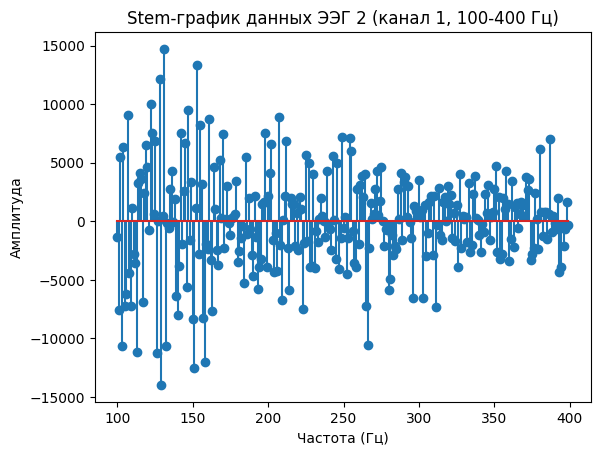

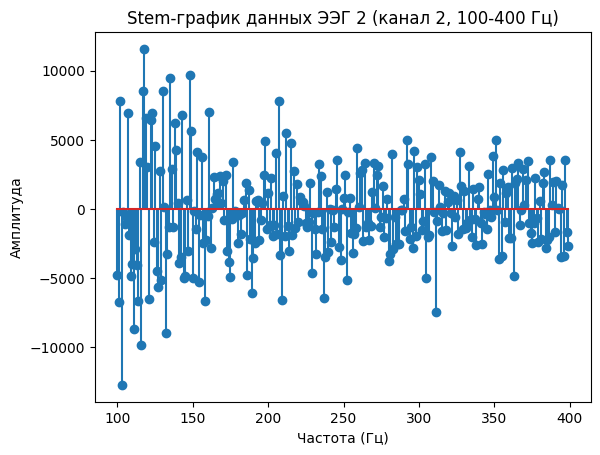

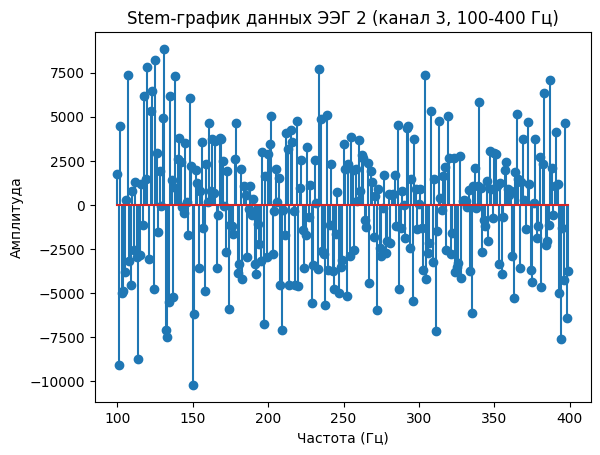

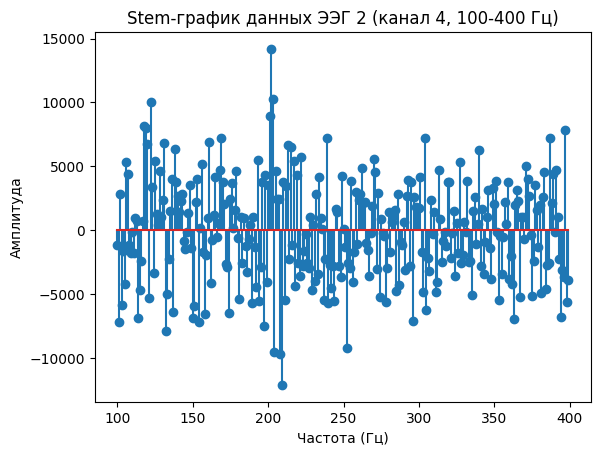

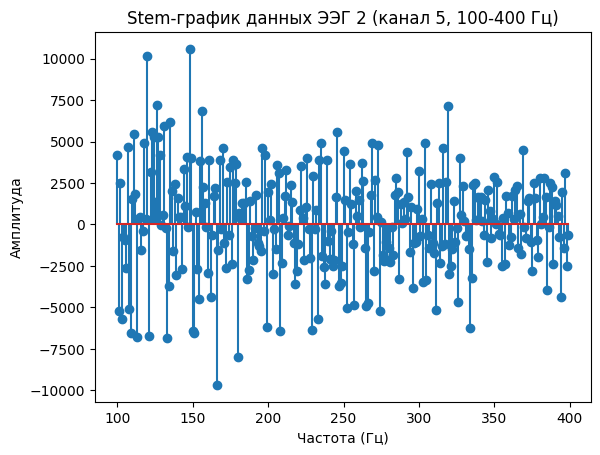

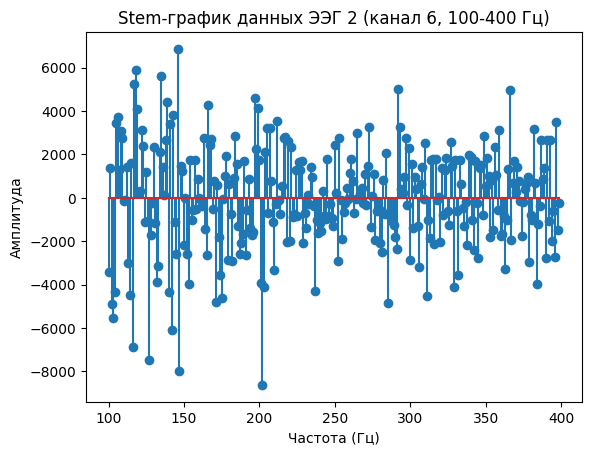

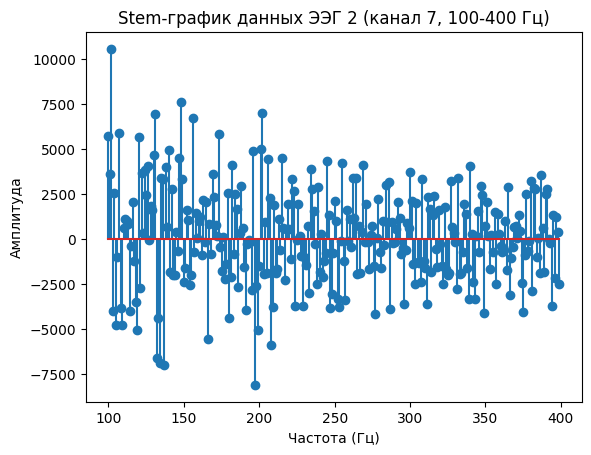

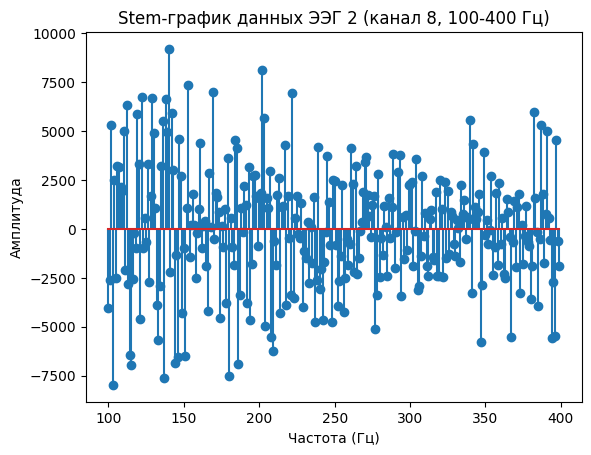

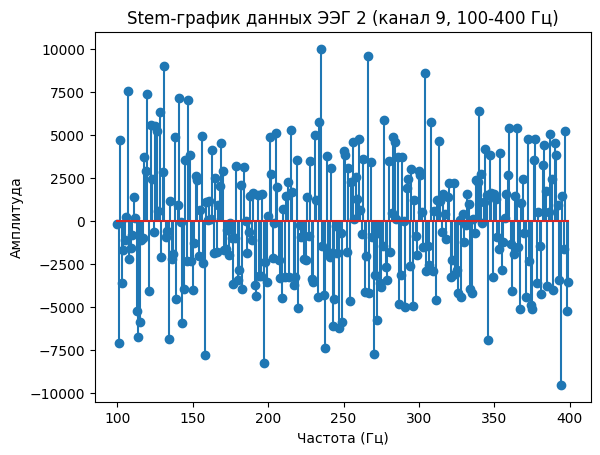

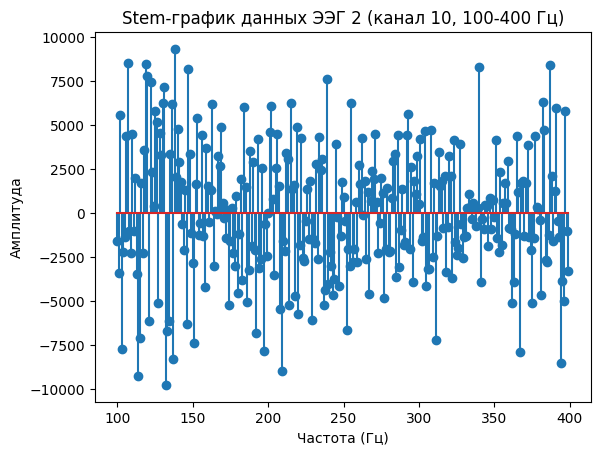

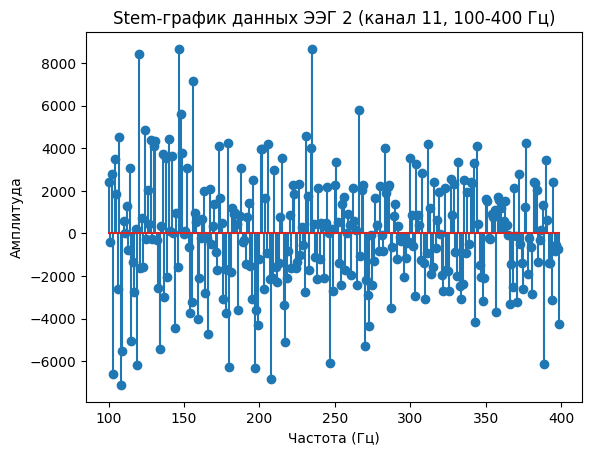

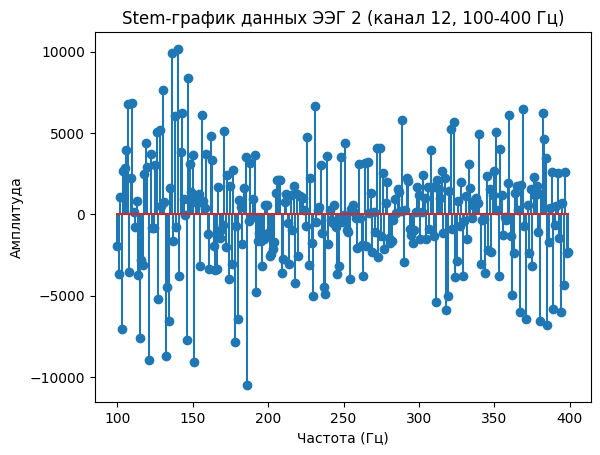

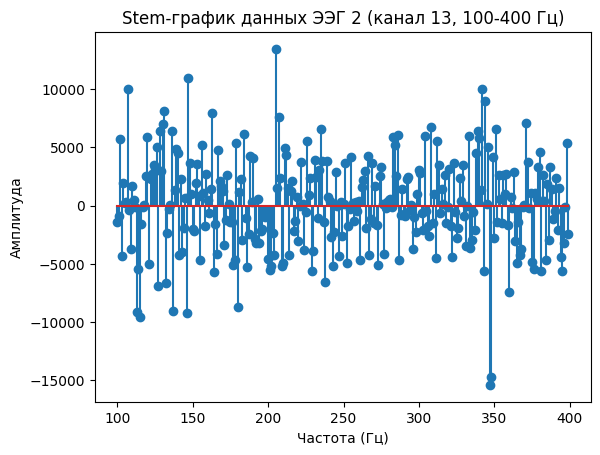

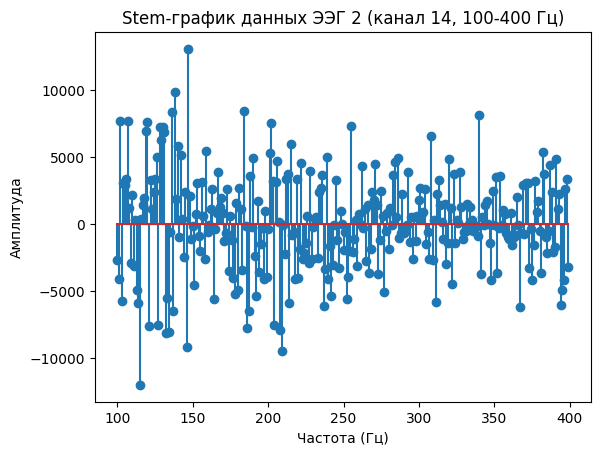

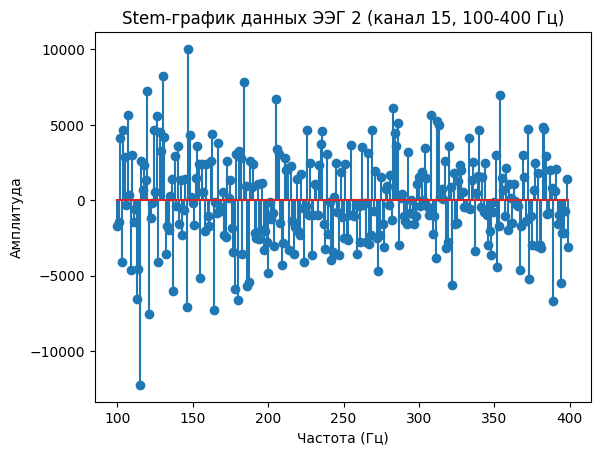

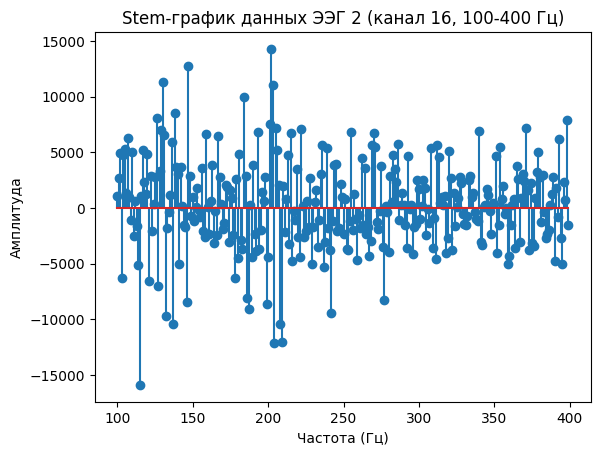

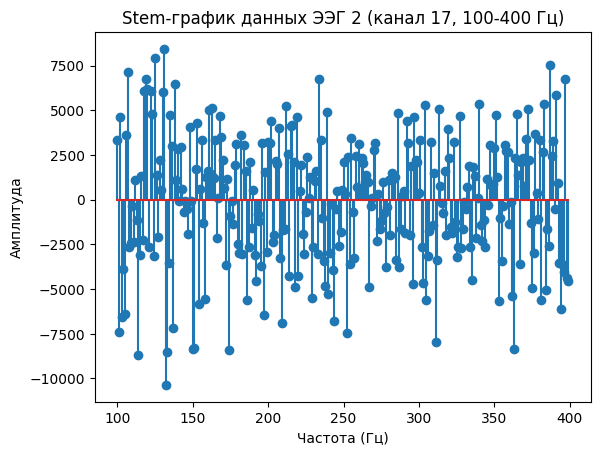

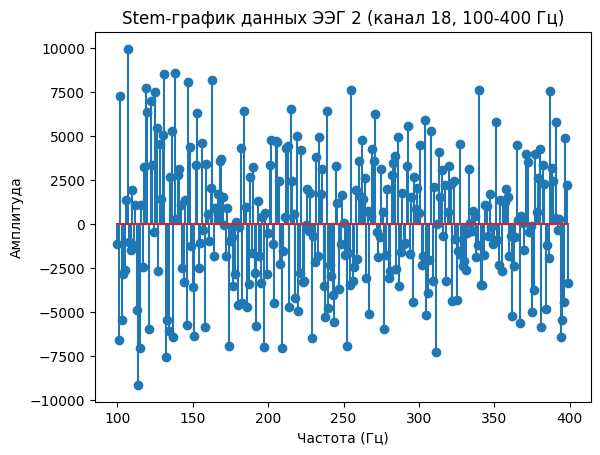

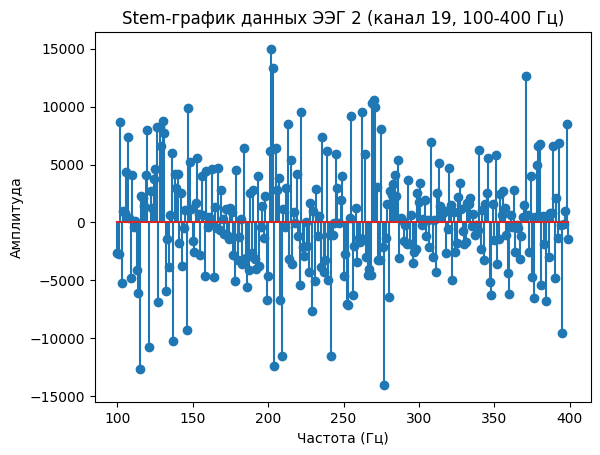

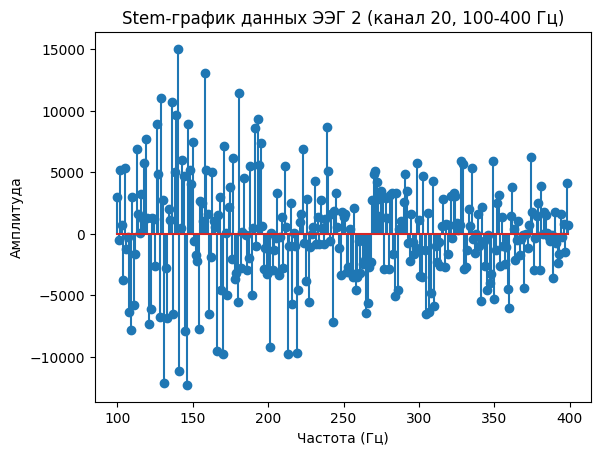

In [ ]:
# Графики ЭЭГ для второго файла

# Задать диапазон частот (100-400 Гц)
freq_range = np.arange(100, 400, 1)

fft_eeg_2 = np.fft.fft(eeg_signals2)
fft_eeg_100_400_2 = fft_eeg_2[:, 100:400]

for i in range(20):
    plt.stem(freq_range, fft_eeg_100_400_2[i, :])
    plt.xlabel("Частота (Гц)")
    plt.ylabel("Амплитуда")
    plt.title(f"Stem-график данных ЭЭГ 2 (канал {i+1}, 100-400 Гц)")
    plt.show()

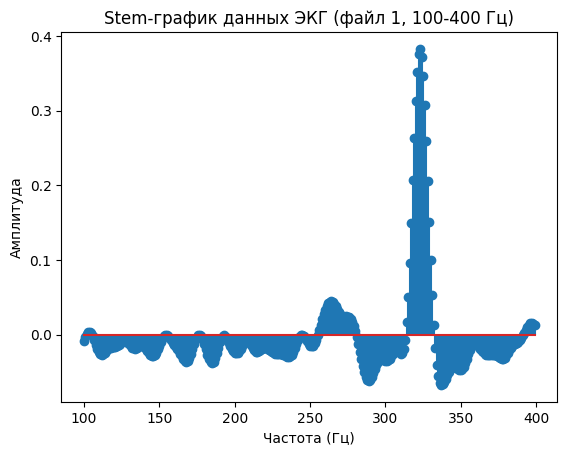

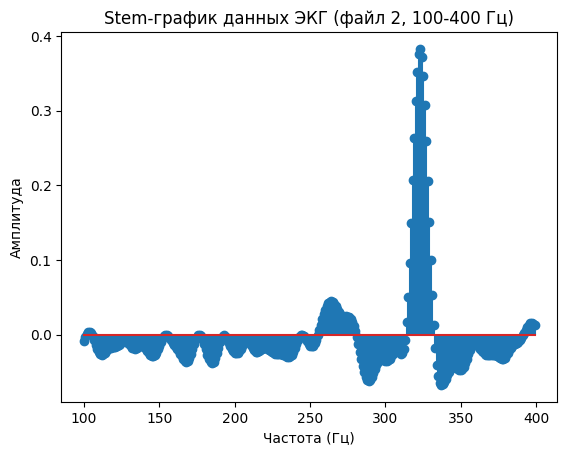

In [ ]:
# Графики ЭКГ для обоих файлов

fft_ecg1 = signals_1[20]
fft_ecg2 = signals_2[20]

# Преобразовать в массив NumPy
fft_ecg1_array = np.array(fft_ecg1)
fft_ecg2_array = np.array(fft_ecg2)

# Отобрать значения в диапазоне 100:400
fft_ecg1_100_400 = fft_ecg1_array[100:400]

# Отобрать значения в диапазоне 100:400
fft_ecg2_100_400 = fft_ecg1_array[100:400]

fft_ecg = (fft_ecg1_100_400, fft_ecg2_100_400)

for i in range(2):
    plt.stem(freq_range, fft_ecg[i])
    plt.xlabel("Частота (Гц)")
    plt.ylabel("Амплитуда")
    plt.title(f"Stem-график данных ЭКГ (файл {i+1}, 100-400 Гц)")
    plt.show()

In [ ]:
# Преобразование Фурье для сигналов ЭЭГ по каналам
from scipy.fft import rfft, rfftfreq, fft

# Применить Фурье-преобразование и получить частотную составляющую в относительных единицах

# Для первого файла
f_data1 = eeg_signals1.copy()
for i in range(len(f_data1)):
    eeg_signals1_array = np.array(eeg_signals1[i])
    f_data1[i] = fft(eeg_signals1_array)

print(f_data1)

# Для второго файла
f_data2 = eeg_signals2.copy()
for i in range(len(f_data2)):
    eeg_signals2_array = np.array(eeg_signals2[i])
    f_data2[i] = fft(eeg_signals2_array)

print(f_data2)

[array([3111.62017896  -0.j        , 3206.85155912+173.76942286j,
       3196.9526212 +343.98407645j, ..., 3177.81637346-514.0243112j ,
       3196.9526212 -343.98407645j, 3206.85155912-173.76942286j]), array([296.04260641 -0.j        , 369.41875759+13.25241975j,
       370.20696163+31.47026967j, ..., 371.52113145-47.19742928j,
       370.20696163-31.47026967j, 369.41875759-13.25241975j]), array([-1791.43872616  -0.j        , -1721.46652916 -72.92226344j,
       -1714.17850388-144.24436266j, ..., -1702.55772853+215.30623676j,
       -1714.17850388+144.24436266j, -1721.46652916 +72.92226344j]), array([-4169.61848411  -0.j        , -4072.05838382-169.03542941j,
       -4056.20688974-337.51850156j, ..., -4031.949559  +505.08932073j,
       -4056.20688974+337.51850156j, -4072.05838382+169.03542941j]), array([-4258.274207    -0.j        , -4162.79099602-190.7640445j ,
       -4147.71383505-378.75894079j, ..., -4122.10316959+565.25503694j,
       -4147.71383505+378.75894079j, -4162.79099602+

In [ ]:
# Вот тут как-то совсем не уверена, то ли делаю...

In [ ]:
# Преобразование данных с учётом полученной ранее частоты

# Для первого файла
freq1 = eeg_signals1.copy()
for i in range(len(freq1)):
  freq1[i] =  rfftfreq(len(eeg_signals1[i]), 1./500)

print(freq1)

# Для второго файла
freq2 = eeg_signals2.copy()
for i in range(len(freq2)):
  freq2[i] =  rfftfreq(len(eeg_signals2[i]), 1./500)

print(freq2)

[array([0.00000000e+00, 5.49450549e-03, 1.09890110e-02, ...,
       2.49989011e+02, 2.49994505e+02, 2.50000000e+02]), array([0.00000000e+00, 5.49450549e-03, 1.09890110e-02, ...,
       2.49989011e+02, 2.49994505e+02, 2.50000000e+02]), array([0.00000000e+00, 5.49450549e-03, 1.09890110e-02, ...,
       2.49989011e+02, 2.49994505e+02, 2.50000000e+02]), array([0.00000000e+00, 5.49450549e-03, 1.09890110e-02, ...,
       2.49989011e+02, 2.49994505e+02, 2.50000000e+02]), array([0.00000000e+00, 5.49450549e-03, 1.09890110e-02, ...,
       2.49989011e+02, 2.49994505e+02, 2.50000000e+02]), array([0.00000000e+00, 5.49450549e-03, 1.09890110e-02, ...,
       2.49989011e+02, 2.49994505e+02, 2.50000000e+02]), array([0.00000000e+00, 5.49450549e-03, 1.09890110e-02, ...,
       2.49989011e+02, 2.49994505e+02, 2.50000000e+02]), array([0.00000000e+00, 5.49450549e-03, 1.09890110e-02, ...,
       2.49989011e+02, 2.49994505e+02, 2.50000000e+02]), array([0.00000000e+00, 5.49450549e-03, 1.09890110e-02, ...,
   

In [ ]:
# Спектральная мощность в 1 и во 2 файле
spectr1 = np.abs(f_data1.copy())
spectr2 = np.abs(f_data2.copy())

print(f"Спектральная мощность сигналов в 1 файле: {spectr1}")
print(f"Спектральная мощность сигналов во 2 файле: {spectr2}")

Спектральная мощность сигналов в 1 файле: [[3111.62017896 3211.55612353 3215.40527881 ... 3219.12067122
  3215.40527881 3211.55612353]
 [ 296.04260641  369.65638787  371.54215415 ...  374.50707396
   371.54215415  369.65638787]
 [1791.43872616 1723.01035039 1720.23672188 ... 1716.11759345
  1720.23672188 1723.01035039]
 ...
 [ 569.60802443  475.88755961  477.28577944 ...  482.06792382
   477.28577944  475.88755961]
 [ 843.82818222  741.38930908  744.02300703 ...  748.2871144
   744.02300703  741.38930908]
 [ 431.75384952  402.15448988  401.62553133 ...  401.31596118
   401.62553133  402.15448988]]
Спектральная мощность сигналов во 2 файле: [[2951.13427691 2922.21381148 2899.03207596 ... 2861.52049821
  2899.03207596 2922.21381148]
 [2215.59311996 2178.90276247 2162.34201415 ... 2141.60080157
  2162.34201415 2178.90276247]
 [ 447.96604945  466.23758514  485.24054721 ...  514.7913835
   485.24054721  466.23758514]
 ...
 [ 349.43112051  338.04586792  341.05868707 ...  346.64950845
   341.

/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


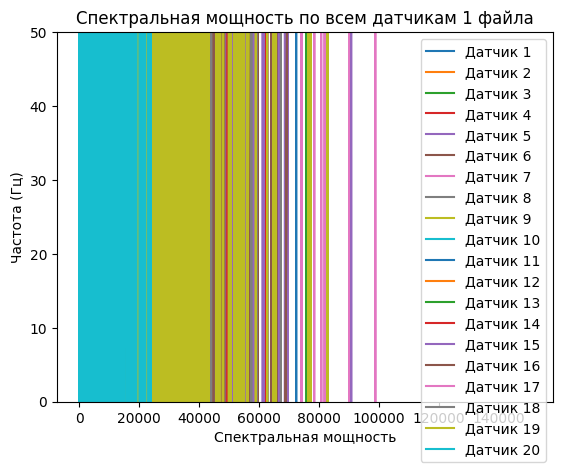

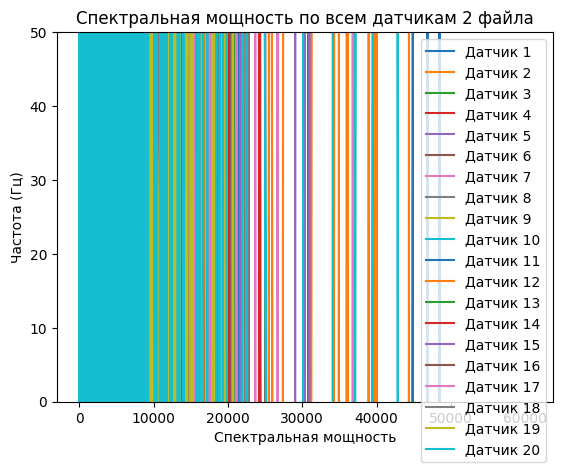

In [ ]:
# Определение диапазона частот для построения графиков
freq_range = (0, 50, 1)

# Построение графиков для каждого датчика первого файла
for i in range(20):
    plt.plot(spectr1[i], f_data1[i], label=f"Датчик {i + 1}")

# Настройка графика
plt.ylabel("Частота (Гц)")
plt.xlabel("Спектральная мощность")
plt.title("Спектральная мощность по всем датчикам 1 файла")
plt.legend()
plt.ylim(freq_range[0], freq_range[1])

plt.show()

# Построение графиков для каждого датчика второго файла
for i in range(20):
    plt.plot(spectr2[i], f_data2[i], label=f"Датчик {i + 1}")

# Настройка графика
plt.ylabel("Частота (Гц)")
plt.xlabel("Спектральная мощность")
plt.title("Спектральная мощность по всем датчикам 2 файла")
plt.legend()
plt.ylim(freq_range[0], freq_range[1])

plt.show()

In [ ]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='bandpass')
    y = filtfilt(b, a, data)
    return y


In [ ]:
from scipy.signal import butter,  filtfilt

# Создание пустого массива для хранения отфильтрованных данных
cut_f_data1 = np.zeros_like(f_data1)
cut_f_data2 = np.zeros_like(f_data2)

# Применение фильтрации для каждого датчика 1 файла
for i in range(20):
    cut_f_data1[i] = butter_bandpass_filter(f_data1[i], 7, 40, 500)

# Применение фильтрации для каждого датчика 2 файла
for i in range(20):
    cut_f_data2[i] = butter_bandpass_filter(f_data2[i], 7, 40, 500)

/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


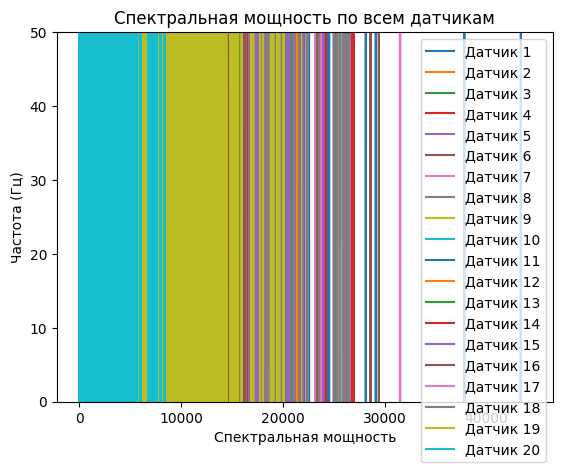

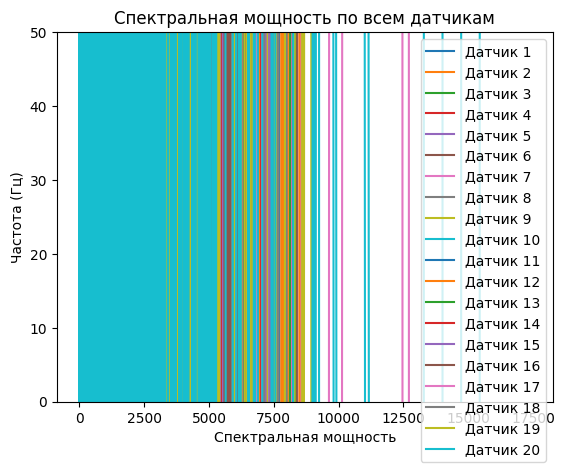

In [ ]:
# Определение диапазона частот для построения графиков
freq_range = (0, 50)
cut_power_spectra_1 = np.abs(cut_f_data1)
cut_power_spectra_2 = np.abs(cut_f_data2)

# Построение графиков для каждого датчика первого файла
for i in range(20):
    plt.plot(cut_power_spectra_1[i], f_data1[i], label=f"Датчик {i + 1}")

# Настройка графика
plt.ylabel("Частота (Гц)")
plt.xlabel("Спектральная мощность")
plt.title("Спектральная мощность по всем датчикам")
plt.legend()
plt.ylim(freq_range[0], freq_range[1])

plt.show()

# Построение графиков для каждого датчика второго файла
for i in range(20):
    plt.plot(cut_power_spectra_2[i], f_data2[i], label=f"Датчик {i + 1}")

# Настройка графика
plt.ylabel("Частота (Гц)")
plt.xlabel("Спектральная мощность")
plt.title("Спектральная мощность по всем датчикам")
plt.legend()
plt.ylim(freq_range[0], freq_range[1])

plt.show()

In [ ]:
from scipy.fft import irfft

# Выполнение обратного Фурье-преобразования для каждого датчика первого файла
ff_data1 = np.zeros((20, 181998))
for i in range(20):
    ff_data1[i] = irfft(cut_f_data1[i])

# Выполнение обратного Фурье-преобразования для каждого датчика второго файла
ff_data2 = np.zeros((20, 61998))
for i in range(20):
    ff_data2[i] = irfft(cut_f_data2[i])

In [ ]:
# С графиками как-то вообще-вообще не уверена :(

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


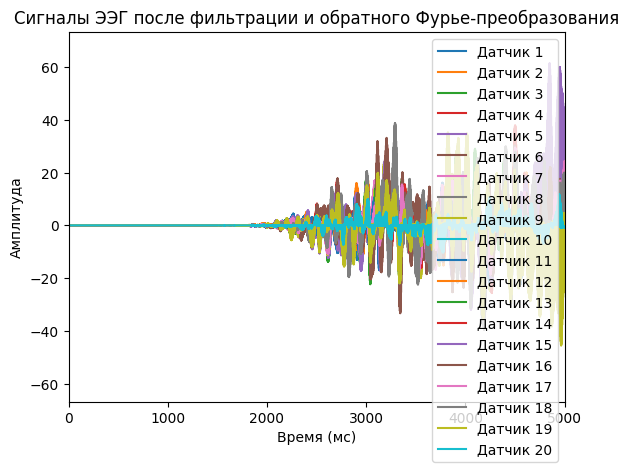

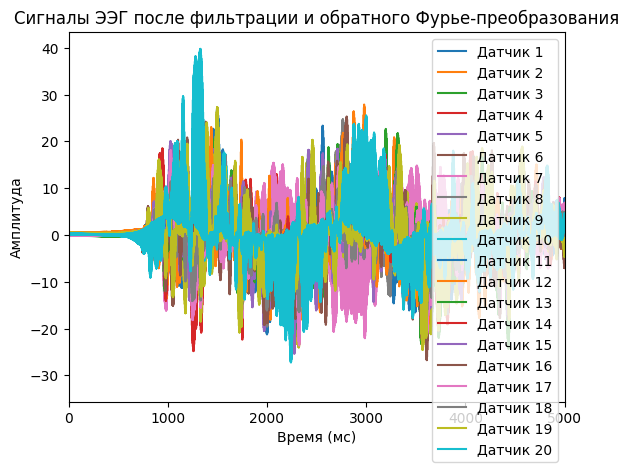

In [ ]:
# Определение временного диапазона
time_range =  (0, 5000)
x_1 = list(range(0, 181998))
x_2 = list(range(0, 61998))

# Построение графиков для каждого датчика первого файла
for i in range(20):
    plt.plot(x_1, ff_data1[i], label=f"Датчик {i + 1}")

# Настройка графика
plt.xlabel("Время (мс)")
plt.ylabel("Амплитуда")
plt.title("Сигналы ЭЭГ после фильтрации и обратного Фурье-преобразования")
plt.legend()
plt.xlim(time_range[0], time_range[1])

plt.show()

# Построение графиков для каждого датчика второго файла
for i in range(20):
    plt.plot(x_2, ff_data2[i], label=f"Датчик {i + 1}")

# Настройка графика
plt.xlabel("Время (мс)")
plt.ylabel("Амплитуда")
plt.title("Сигналы ЭЭГ после фильтрации и обратного Фурье-преобразования")
plt.legend()
plt.xlim(time_range[0], time_range[1])

plt.show()

In [ ]:
# Можно заметить, что амплитуды сигналов во втором файле в среднем выше на протяжении записи, что указывает на постоянную умственную активность при решении задач